Pract 2A

In [8]:
import pandas as pd

df = pd.read_excel('C:/Users/Admin/Downloads/Product-Sales-Region.xlsx')

print(df.head())

        Date   Region Product  Quantity  UnitPrice StoreLocation CustomerType  \
0 2023-02-23     East  Laptop        14     163.60       Store B    Wholesale   
1 2024-12-19    South   Phone         1     544.01       Store A       Retail   
2 2023-05-10    North    Desk        14     346.18       Store B    Wholesale   
3 2025-02-26  Central   Chair        18     384.82       Store A    Wholesale   
4 2023-06-24     East    Desk        18     237.76       Store C       Retail   

   Discount Salesperson  TotalPrice PaymentMethod Promotion  Returned  \
0      0.00         Eva    2290.400        Online  FREESHIP         0   
1      0.00       Alice     544.010     Gift Card    SAVE10         0   
2      0.10       Alice    4361.868        Online  WINTER15         0   
3      0.15       Frank    5887.746     Gift Card  FREESHIP         0   
4      0.00      Carlos    4279.680        Online    SAVE10         0   

     OrderID CustomerName  ShippingCost  OrderDate DeliveryDate RegionMana

In [4]:
from sklearn.linear_model import LinearRegression

X = df[['Quantity']]   
y = df['TotalPrice']   

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])


Intercept: -131.72366159260537
Slope: 293.13383202413604


In [9]:
df['PredictedPrice'] = model.predict(X)

print(df[['Quantity', 'TotalPrice', 'PredictedPrice']].head())


   Quantity  TotalPrice  PredictedPrice
0        14    2290.400     3972.149987
1         1     544.010      161.410170
2        14    4361.868     3972.149987
3        18    5887.746     5144.685315
4        18    4279.680     5144.685315


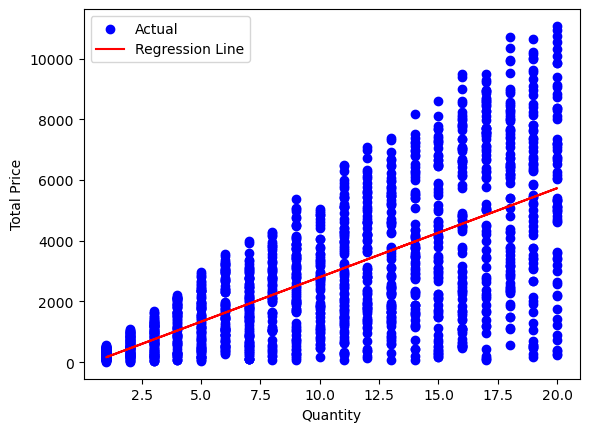

In [6]:
import matplotlib.pyplot as plt

plt.scatter(df['Quantity'], df['TotalPrice'], color='blue', label='Actual')
plt.plot(df['Quantity'], df['PredictedPrice'], color='red', label='Regression Line')
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.legend()
plt.show()


Pract 2B

In [2]:
import pandas as pd

df = pd.read_excel('C:/Users/Admin/Downloads/Product-Sales-Region.xlsx')

In [12]:
X = df[['Quantity', 'UnitPrice', 'Discount', 'ShippingCost']]

y = df['TotalPrice']

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Intercept: -2648.9296536354104
Coefficients: [ 2.81616863e+02  9.70463748e+00 -3.41179078e+03 -4.86643349e-01]


In [14]:
df['PredictedPrice'] = model.predict(X)

print(df[['Quantity', 'UnitPrice', 'Discount', 'ShippingCost', 'TotalPrice', 'PredictedPrice']].head())


   Quantity  UnitPrice  Discount  ShippingCost  TotalPrice  PredictedPrice
0        14     163.60      0.00         43.34    2290.400     2860.294003
1         1     544.01      0.00          5.30     544.010     2909.527836
2        14     346.18      0.10         20.46    4361.868     4302.122036
3        18     384.82      0.15         27.95    5887.746     5629.342185
4        18     237.76      0.00          5.73    4279.680     4724.760029


In [15]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y, df['PredictedPrice'])
mse = mean_squared_error(y, df['PredictedPrice'])

print("R² Score:", r2)
print("Mean Squared Error:", mse)


R² Score: 0.871669085564712
Mean Squared Error: 816213.6555353509


Pract 2C

In [4]:
import pandas as pd

df = pd.read_excel('C:/Users/Admin/Downloads/Product-Sales-Region.xlsx')

In [5]:
X = df[['Quantity']]
y = df['TotalPrice']

In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 93.18083822132849
Coefficients: [  0.         231.19358236   2.97280728]


In [7]:
y_pred = model.predict(X_poly)

df['PredictedPrice_Poly'] = y_pred
print(df[['Quantity', 'TotalPrice', 'PredictedPrice_Poly']].head())

   Quantity  TotalPrice  PredictedPrice_Poly
0        14    2290.400          3912.561218
1         1     544.010           327.347228
2        14    4361.868          3912.561218
3        18    5887.746          5217.854880
4        18    4279.680          5217.854880


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


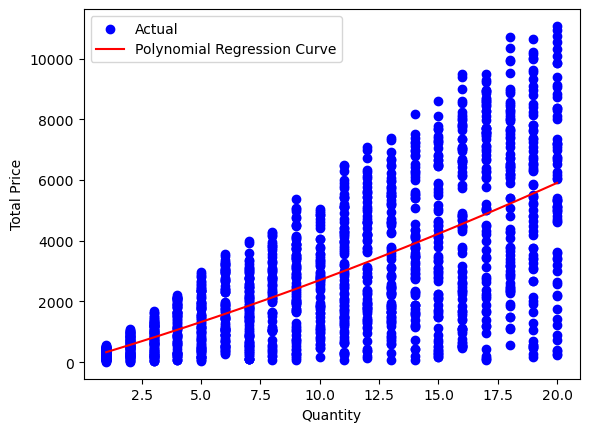

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(df['Quantity'], df['TotalPrice'], color='blue', label='Actual')

X_range = np.linspace(df['Quantity'].min(), df['Quantity'].max(), 200).reshape(-1,1)
X_range_poly = poly.transform(X_range)
y_range_pred = model.predict(X_range_poly)

plt.plot(X_range, y_range_pred, color='red', label='Polynomial Regression Curve')
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.legend()
plt.show()